# SpatioEv Phenotyping Development Test

This notebook demonstrates the human-in-the-loop phenotyping workflow in SpatioEv.

Workflow:

1. Load dataset
2. Perform level-0 clustering
3. Inspect clusters spatially
4. Annotate clusters
5. Subset populations
6. Perform refinement clustering
7. Merge results back

In [1]:
import spatioev as se
import scanpy as sc
import pandas as pd

from spatioev.config import ClusteringConfig

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
import os
# set a working directory
wdir = ('/Users/shihongwu/SpatioEv')
os.chdir(wdir)

### Load test dataset

In [3]:
adata = se.load_h5ad("data/exp_1.h5ad")
adata

AnnData object with n_obs × n_vars = 51932 × 25
    obs: 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 'fractal_dimension', 'boundary_irregularity', 'nc_ratio', 'cell_size_nuclear', 'CD11c_nuclear', 'CD14_nuclear', 'CD146_nuclear', 'CD19_nuclear', 'CD3_nuclear', 'CD31_nuclear', 'CD4_nuclear', 'CD45_nuclear', 'CD68_nuclear', 'CD90_nuclear', 'CK19_nuclear', 'COL1A1_nuclear', 'COL4A1_nuclear', 'COL6A1_nuclear', 'FN_nuclear', 'HLADR_nuclear', 'IGFBP5_nuclear', 'NaKATPase_nuclear', 'PCK_nuclear', 'PDPN_nuclear', 'RS6_nuclear', 'SMA_nuclear', 'Tenascin_nuclear', 'Vimentin_nuclear', 'dapi_nuclear', 'label_nuclear', 'area_nuclear', 'eccentricity_nuclear', 'major_axis_length_nuclear', 'min

In [4]:
# List layer names
print(list(adata.layers.keys()))

# Number of layers
print(len(adata.layers))

# Show each layer name + shape + dtype
for k in adata.layers.keys():
    arr = adata.layers[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

[]
0


### Define Level-0 Phenotyping Configuration 
This is the initial clustering across all cells.

In [5]:
level0_config = ClusteringConfig(

    markers=[
        "DNA_1",
        "PCK", 
        "CD45",
        "SMA", "FN", "COL6A1",
        "COL4A1"
    ],

    n_neighbors=10,
    n_pcs=15,
    resolution=0.2,

    scale=True
)

Run Level-0 clustering

In [6]:
adata = se.zscore_normalize(adata)
adata_lvl0 = se.cluster_cells(adata, level0_config)

/Users/shihongwu/SpatioEv/spatioev/phenotype/clustering.py:20: FutureWarning:

In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.



Visualize clusters (UMAP)

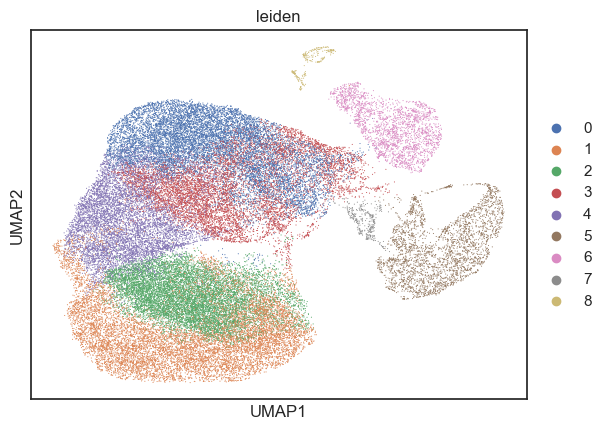

In [7]:
sc.pl.umap(
    adata_lvl0,
    color="leiden"
)

Visualize cluster marker expression

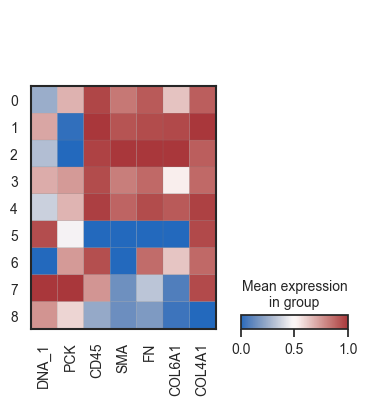

In [8]:
se.plot_cluster_heatmap(
    adata_lvl0,
    level0_config.markers
)

Inspect clusters spatially

In [9]:
image_path = "background/OnTIMEr18_n_a_backsub.ome.tif"

In [10]:
se.inspect_clusters(
    adata_lvl0,
    image_path=image_path,
    label="leiden",
)


Inspect clusters in napari. Close the viewer to continue.



Annotate clusters interactively

In [10]:
adata_lvl0, mapping_lvl0 = se.annotate_interactive(
    adata_lvl0,
    cluster_key="leiden",
    new_key="annotation"
)


Enter annotation for each cluster



View annotated clusters

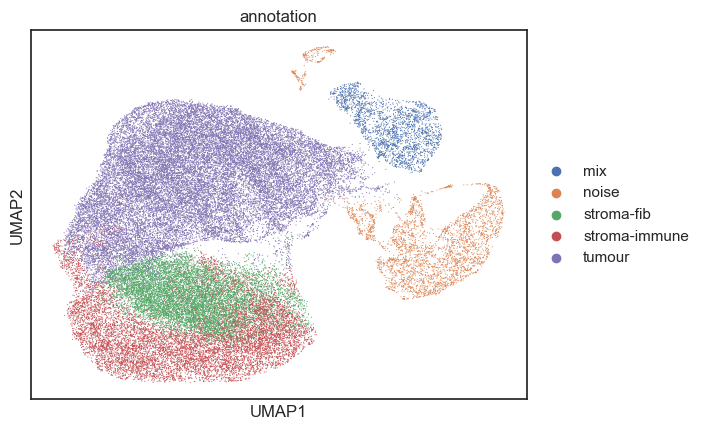

In [11]:
sc.pl.umap(
    adata_lvl0,
    color="annotation"
)

Subset clusters of interest for refinement

In [12]:
clusters_to_refine = [
    "stroma-immune",
    "stroma-fib",
    "tumour",
    "mix",
]

configs = {

    "stroma-immune": ClusteringConfig(
        
        markers=[
            "DNA_1","PCK", "CD45","SMA", "FN", "COL6A1","COL4A1"
        ],
        resolution=0.5
    ),

    "stroma-fib": ClusteringConfig(
       
        markers=[
            "DNA_1","PCK", "CD45","SMA", "FN", "COL6A1","COL4A1"
        ],
        resolution=0.5
    ),

    "tumour": ClusteringConfig(
        
        markers=[
            "DNA_1","PCK", "CD45","SMA", "FN", "COL6A1","COL4A1"
        ],
        resolution=0.5
    ),

    "mix": ClusteringConfig(
        
        markers=[
            "DNA_1","PCK", "CD45","SMA", "FN", "COL6A1","COL4A1"
        ],
        resolution=0.5
    )
}

In [13]:
refined = se.refine_clusters(
    adata_lvl0,
    clusters_to_refine,
    configs,
    annotation_key="annotation",
)

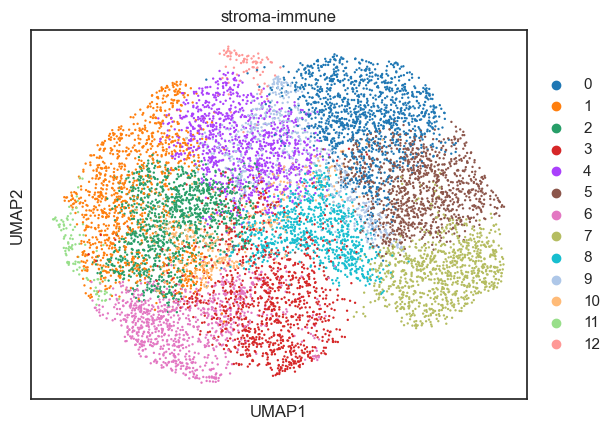

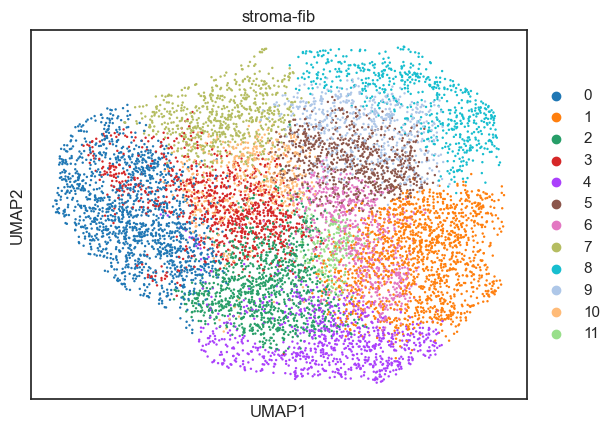

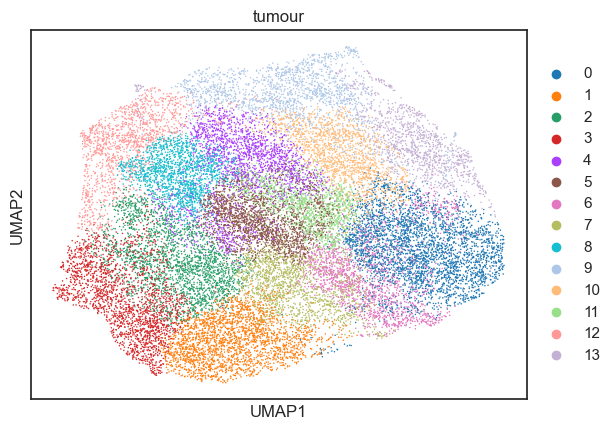

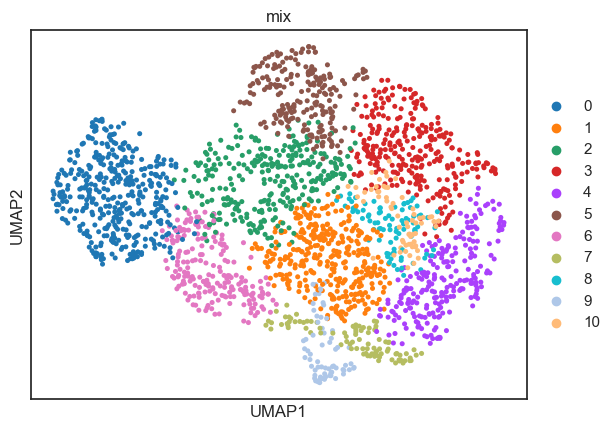

In [14]:
se.plot_refinement_umaps(refined)

In [15]:
annotated, mappings = se.annotate_refinements(
    refined,
    image_path=image_path
)


Inspecting stroma-immune


Inspect clusters in napari. Close the viewer to continue.


Enter annotation for each cluster


Inspecting stroma-fib


Inspect clusters in napari. Close the viewer to continue.


Enter annotation for each cluster


Inspecting tumour


Inspect clusters in napari. Close the viewer to continue.


Enter annotation for each cluster


Inspecting mix


Inspect clusters in napari. Close the viewer to continue.


Enter annotation for each cluster



In [16]:
adata_final = se.merge_refinements(
    adata_lvl0,
    annotated,
    new_key="annotation_level2"
)

Visualize refined annotation

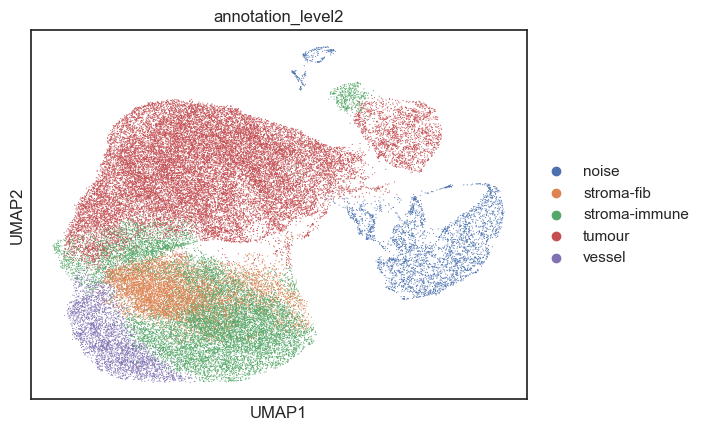

In [17]:
sc.pl.umap(
    adata_final,
    color="annotation_level2"
)

Spatial visualization of refined annotation

In [19]:
se.inspect_clusters(
    adata_final,
    image_path=image_path,
    label="annotation_level2"
)


Inspect clusters in napari. Close the viewer to continue.



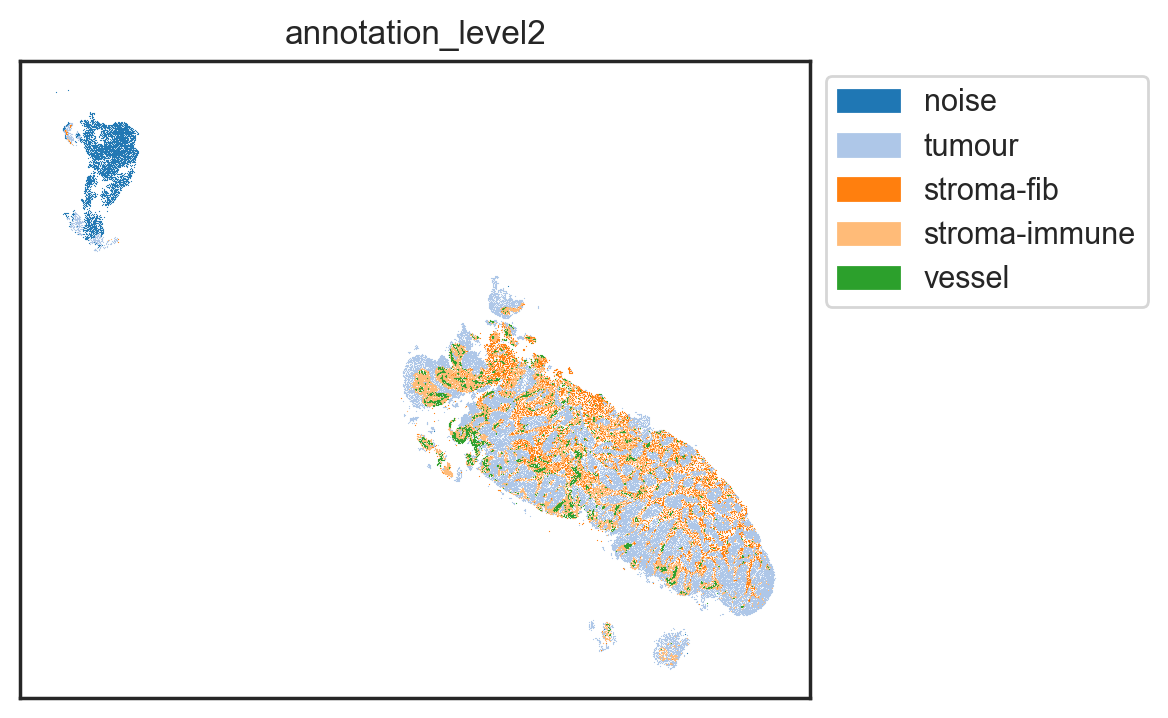

In [18]:
se.spatial_scatter_plot(
    adata_final,
    colorBy="annotation_level2",
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    figsize=(6,6)
)

Save phenotyping results

In [20]:
adata_final.obs[
    ["annotation","annotation_level2"]
].to_csv(
    "results/phenotyping_annotations.csv"
)